# Résultats — charts de lecture de /lit/ comme dispositifs gamifiés

Ce notebook charge les tableaux consolidés de `data/processed/` et produit les
tableaux et figures destinés au papier. Chaque figure est enregistrée dans
`results/` et suivie d'un commentaire de lecture.

**Provenance des données** (voir `CLAUDE.md`) : OCR local (moteur Vision,
contrôlable par Surya), reconstruction géométrique des blocs, marqueurs lexicaux
déterministes (`prompts/marqueurs.json`), auteurs nettoyés et normalisés
(`09_auteurs.py`). La colonne `layout_manuel` (forme des 264 charts) a été codée
par un modèle vision-langage distant (Claude) et sert de **validation externe** —
elle n'entre dans aucun calcul d'apprentissage.

**Reproductibilité** : toutes les graines aléatoires sont fixées ; relancer le
notebook reproduit les mêmes chiffres et les mêmes figures. Conformément au
`CLAUDE.md`, ce notebook relève de l'exploration : la logique de clustering, une
fois stabilisée, a vocation à migrer vers `src/10_cluster.py`.

In [1]:
# --- Chargement et réglages communs ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RACINE = Path("..").resolve()
PROC, RESULTS = RACINE / "data" / "processed", RACINE / "results"
RESULTS.mkdir(exist_ok=True)
np.random.seed(42)

# Palette validée (réf. : skill dataviz) — une teinte par rôle, jamais recyclée.
BLEU, VERT, MAGENTA, JAUNE = "#2a78d6", "#008300", "#e87ba4", "#eda100"
ENCRE, ENCRE2, GRILLE = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 10, "axes.edgecolor": ENCRE2, "axes.labelcolor": ENCRE,
    "text.color": ENCRE, "xtick.color": ENCRE2, "ytick.color": ENCRE2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRILLE, "grid.linewidth": 0.8,
})

def figure(nom, fig):
    """Enregistre la figure dans results/ puis l'affiche."""
    fig.savefig(RESULTS / nom)
    plt.show()

charts  = pd.read_csv(PROC / "charts.csv")
oeuvres = pd.read_csv(PROC / "oeuvres.csv")
traits  = pd.read_csv(PROC / "traits.csv")
auteurs = pd.read_csv(PROC / "auteurs.csv")
print(f"charts  : {charts.shape[0]} lignes × {charts.shape[1]} colonnes")
print(f"oeuvres : {oeuvres.shape[0]} lignes   auteurs (nettoyés) : {auteurs.shape[0]} lignes")
print(f"traits  : {traits.shape[0]} charts × {traits.shape[1]} colonnes")

charts  : 264 lignes × 31 colonnes
oeuvres : 34581 lignes   auteurs (nettoyés) : 5518 lignes
traits  : 264 charts × 22 colonnes


## 1. Le corpus par formes

La forme de chaque chart a été codée sur les 264 images selon une taxonomie en
sept modalités construite inductivement (deux catégories ont dû être ajoutées en
cours de codage, la taxonomie initiale ne rendant pas compte du corpus).

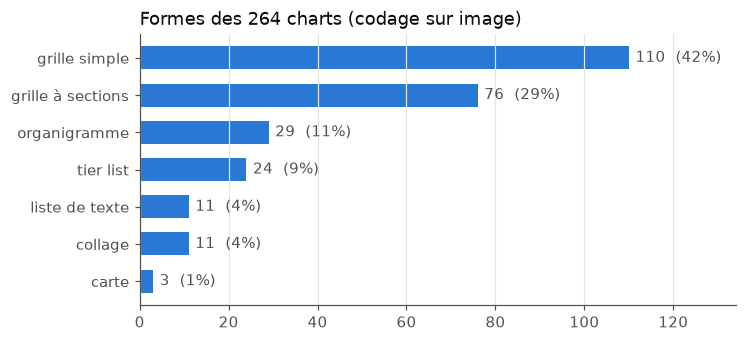

catalogues (grilles + collages) : 197 (75%)
prescriptifs (organigrammes + tier lists) : 53 (20%)


In [2]:
formes = traits["layout_manuel"].value_counts()
libelles = {"grid": "grille simple", "sectioned_grid": "grille à sections",
            "flowchart": "organigramme", "tier_list": "tier list",
            "list": "liste de texte", "collage": "collage", "map": "carte"}

fig, ax = plt.subplots(figsize=(7, 3.2))
y = np.arange(len(formes))[::-1]
ax.barh(y, formes.values, height=0.62, color=BLEU)
ax.set_yticks(y, [libelles.get(f, f) for f in formes.index])
for yi, v in zip(y, formes.values):   # étiquette directe, pas de quadrillage x
    ax.text(v + 1.5, yi, f"{v}  ({v/len(traits):.0%})", va="center", color=ENCRE2)
ax.grid(axis="y", visible=False); ax.set_xlim(0, formes.max() * 1.22)
ax.set_title("Formes des 264 charts (codage sur image)", loc="left")
figure("fig01_formes.png", fig)

catalogues = formes.get("grid",0) + formes.get("sectioned_grid",0) + formes.get("collage",0)
prescriptifs = formes.get("flowchart",0) + formes.get("tier_list",0)
print(f"catalogues (grilles + collages) : {catalogues} ({catalogues/len(traits):.0%})")
print(f"prescriptifs (organigrammes + tier lists) : {prescriptifs} ({prescriptifs/len(traits):.0%})")

**Lecture.** Les trois quarts du corpus (75 %) sont des *catalogues* — grilles
avec ou sans sections, collages — qui juxtaposent des œuvres sans prescrire de
parcours. Les formes structurellement prescriptives (organigrammes, tier lists)
ne représentent que 20 % des charts. Premier résultat : contrairement à ce que
suggère l'imaginaire du « start with the Greeks », la forme dominante du chart
n'est pas le parcours balisé mais le classement. La gamification, si elle opère,
doit donc passer ailleurs que par la forme — c'est l'objet de la section 2.

## 2. Les mécaniques de gamification

Neuf registres lexicaux sont relevés par expressions régulières dans le texte
intégral de chaque chart (`prompts/marqueurs.json`, méthode entièrement
déterministe et vérifiable). Un chart « porte » un registre dès qu'au moins un
marqueur y apparaît.

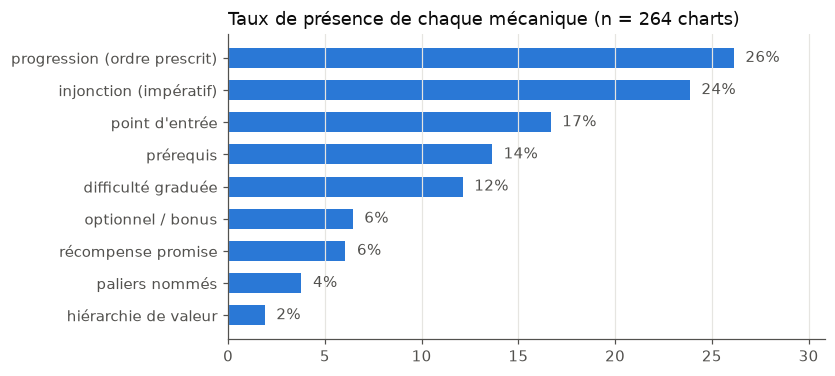

In [3]:
REGISTRES = ["m_progression", "m_injonction", "m_point_entree", "m_prerequis",
             "m_difficulte", "m_optionnel", "m_recompense", "m_niveaux_nommes",
             "m_hierarchie_valeur"]
NOMS = {"m_progression": "progression (ordre prescrit)", "m_injonction": "injonction (impératif)",
        "m_point_entree": "point d'entrée", "m_prerequis": "prérequis",
        "m_difficulte": "difficulté graduée", "m_optionnel": "optionnel / bonus",
        "m_recompense": "récompense promise", "m_niveaux_nommes": "paliers nommés",
        "m_hierarchie_valeur": "hiérarchie de valeur"}

presence = (traits[REGISTRES] > 0).mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.6))
y = np.arange(len(presence))
ax.barh(y, presence.values * 100, height=0.62, color=BLEU)
ax.set_yticks(y, [NOMS[r] for r in presence.index])
for yi, v in zip(y, presence.values):
    ax.text(v * 100 + 0.6, yi, f"{v:.0%}", va="center", color=ENCRE2)
ax.grid(axis="y", visible=False); ax.set_xlim(0, presence.max() * 118)
ax.set_title("Taux de présence de chaque mécanique (n = 264 charts)", loc="left")
figure("fig02_mecaniques.png", fig)

**Lecture.** Aucune mécanique n'est majoritaire. Les plus répandues sont
discursives — un quart des charts prescrit un ordre (26 %) ou s'adresse au
lecteur à l'impératif (24 %) — tandis que les mécaniques les plus « ludiques »
au sens strict, celles qui miment le jeu vidéo (paliers nommés : 4 %,
hiérarchie de valeur type *God-Tier* : 2 %), sont rares. La gamification des
charts de /lit/ est donc d'abord une affaire de *langage prescriptif*, pas de
décorum vidéoludique.

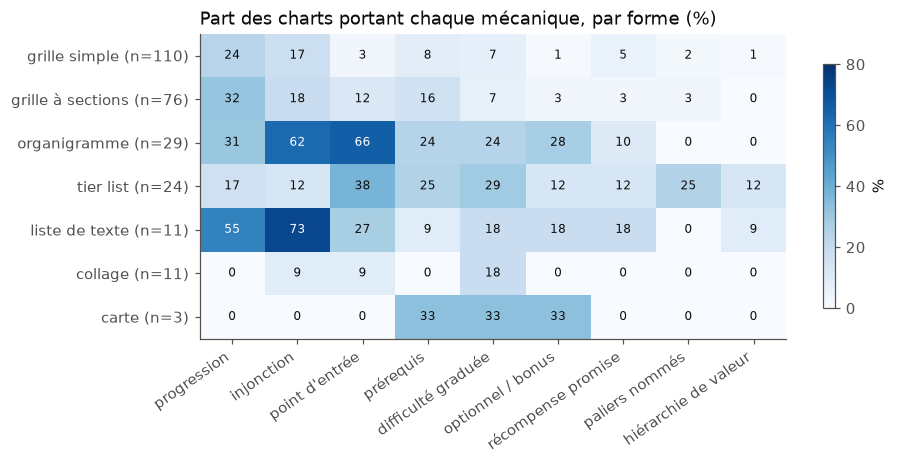

                score moyen  score médian
layout_manuel                            
grid                    0.9           0.0
sectioned_grid          1.4           1.0
flowchart               4.3           3.0
tier_list               4.1           2.0
list                    9.0           5.0
collage                 0.4           0.0
map                     1.0           1.0


In [4]:
# Croisement forme × mécanique : part des charts de chaque forme portant le registre.
ORDRE_F = ["grid", "sectioned_grid", "flowchart", "tier_list", "list", "collage", "map"]
tab = pd.DataFrame({f: (traits.loc[traits["layout_manuel"] == f, REGISTRES] > 0).mean()
                    for f in ORDRE_F}).T * 100
tab.columns = [NOMS[c].split(" (")[0] for c in tab.columns]

fig, ax = plt.subplots(figsize=(8.6, 3.6))
im = ax.imshow(tab.values, cmap="Blues", vmin=0, vmax=80, aspect="auto")
ax.set_xticks(range(tab.shape[1]), tab.columns, rotation=35, ha="right")
effectifs = traits["layout_manuel"].value_counts()
ax.set_yticks(range(tab.shape[0]),
              [f"{libelles[f]} (n={effectifs[f]})" for f in ORDRE_F])
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        v = tab.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                color="white" if v > 45 else ENCRE)
ax.grid(visible=False)
ax.set_title("Part des charts portant chaque mécanique, par forme (%)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.8, label="%")
figure("fig03_forme_x_mecanique.png", fig)

score = traits[REGISTRES].sum(axis=1)
resume = score.groupby(traits["layout_manuel"]).agg(["mean", "median"]).reindex(ORDRE_F)
print(resume.round(1).rename(columns={"mean": "score moyen", "median": "score médian"}))

**Lecture.** Le tableau croisé révèle une *répartition du travail prescriptif*.
Les organigrammes prescrivent doublement : deux tiers désignent un point
d'entrée (66 %) et s'adressent au lecteur à l'impératif (62 %). Les tier lists
commandent peu mais gradent : elles concentrent les paliers nommés (25 %) et la
hiérarchie de valeur (12 %). Surtout, les **listes de texte** — la forme la plus
pauvre visuellement — compensent entièrement par le langage : 73 % d'injonctions
et le score lexical moyen le plus élevé du corpus (8,3 contre 0,9 pour les
grilles, de score médian nul). La gamification n'est pas une propriété de la
forme : c'est une **fonction distribuée** entre l'agencement visuel et
l'énonciation, chaque forme choisissant son canal.

## 3. Typologie émergente (clustering)

Regroupement non supervisé des 264 charts sur les **19 variables mesurables**
(10 de forme issues de l'OCR, 9 de discours) — jamais sur les colonnes de
validation. Méthode : variables de comptage passées au log, standardisation,
K-means (graine fixée), nombre de groupes choisi au silhouette. Les groupes
sont ensuite confrontés au codage des formes et aux catégories thématiques du
wiki (indice de Rand ajusté, ARI).

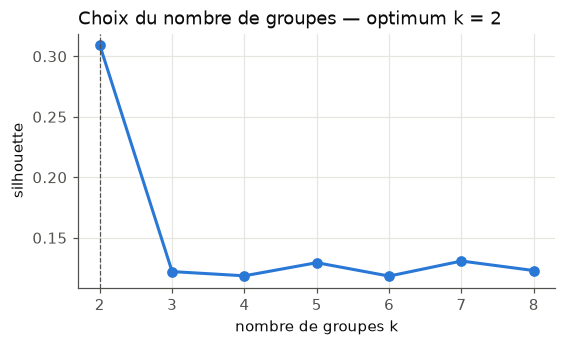

k retenu : 2
ARI clusters × formes codées      : 0.093
ARI clusters × catégories du wiki : 0.018


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

VARS = ["ratio_hauteur_largeur", "nb_lignes", "densite_texte", "couverture_verticale",
        "part_bandes_peuplees", "regularite_colonnes", "cv_hauteurs_lignes",
        "longueur_moyenne_ligne", "part_lignes_courtes", "confiance_mediane"] + REGISTRES
X = traits[VARS].copy()
for c in ["nb_lignes"] + REGISTRES:        # comptages très asymétriques
    X[c] = np.log1p(X[c])
X = StandardScaler().fit_transform(X)

ks = range(2, 9)
sil = [silhouette_score(X, KMeans(k, n_init=10, random_state=42).fit_predict(X))
       for k in ks]
fig, ax = plt.subplots(figsize=(5.6, 3))
ax.plot(list(ks), sil, color=BLEU, linewidth=2, marker="o", markersize=6)
k_opt = list(ks)[int(np.argmax(sil))]
ax.axvline(k_opt, color=ENCRE2, linewidth=0.8, linestyle="--")
ax.set_xlabel("nombre de groupes k"); ax.set_ylabel("silhouette")
ax.set_title(f"Choix du nombre de groupes — optimum k = {k_opt}", loc="left")
figure("fig04_silhouette.png", fig)

km = KMeans(k_opt, n_init=10, random_state=42).fit(X)
traits["cluster"] = km.labels_
print(f"k retenu : {k_opt}")
print(f"ARI clusters × formes codées      : {adjusted_rand_score(traits['cluster'], traits['layout_manuel']):.3f}")
print(f"ARI clusters × catégories du wiki : {adjusted_rand_score(traits['cluster'], traits['categorie']):.3f}")

**Lecture.** La courbe de silhouette guide le choix du nombre de groupes ;
l'optimum est marqué en pointillé. Les deux indices de Rand ajustés situent la
typologie émergente par rapport aux deux classements existants : un ARI proche
de 0 signifierait que les groupes ne recoupent ni la forme ni le thème (ils
capteraient autre chose), un ARI élevé qu'ils redécouvrent un classement déjà
connu. C'est le test central de la phase 4 : la typologie par les *mécaniques*
est-elle réductible à la forme visuelle ou au sujet ?

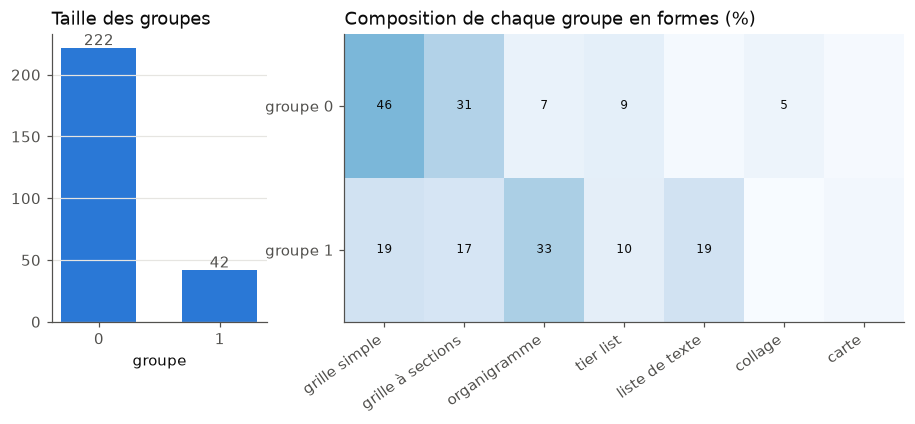

groupe 0 (n=222) : forme dominante grille simple          (46%) | registre sur-représenté : paliers nommés
groupe 1 (n= 42) : forme dominante organigramme           (33%) | registre sur-représenté : injonction (impératif)


In [6]:
# Taille et composition des groupes.
tailles = traits["cluster"].value_counts().sort_index()
compo = pd.crosstab(traits["cluster"], traits["layout_manuel"], normalize="index") * 100
compo = compo[[c for c in ORDRE_F if c in compo.columns]]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4),
                         gridspec_kw={"width_ratios": [1, 2.6]})
axes[0].bar(tailles.index.astype(str), tailles.values, color=BLEU, width=0.62)
for x, v in zip(range(len(tailles)), tailles.values):
    axes[0].text(x, v + 2, str(v), ha="center", color=ENCRE2)
axes[0].grid(axis="x", visible=False)
axes[0].set_title("Taille des groupes", loc="left")
axes[0].set_xlabel("groupe")

im = axes[1].imshow(compo.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
axes[1].set_xticks(range(compo.shape[1]),
                   [libelles[c] for c in compo.columns], rotation=35, ha="right")
axes[1].set_yticks(range(compo.shape[0]), [f"groupe {i}" for i in compo.index])
for i in range(compo.shape[0]):
    for j in range(compo.shape[1]):
        v = compo.values[i, j]
        if v >= 3:
            axes[1].text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                         color="white" if v > 55 else ENCRE)
axes[1].grid(visible=False)
axes[1].set_title("Composition de chaque groupe en formes (%)", loc="left")
figure("fig05_clusters_composition.png", fig)

# Lecture automatique : forme dominante et registre saillant de chaque groupe.
for g in tailles.index:
    sous = traits[traits["cluster"] == g]
    forme_dom = sous["layout_manuel"].mode()[0]
    part = (sous["layout_manuel"] == forme_dom).mean()
    m = (sous[REGISTRES] > 0).mean()
    saillant = (m - (traits[REGISTRES] > 0).mean()).idxmax()
    print(f"groupe {g} (n={len(sous):>3}) : forme dominante {libelles[forme_dom]:<22}"
          f" ({part:.0%}) | registre sur-représenté : {NOMS[saillant]}")

**Lecture.** La composition (panneau droit, en % de chaque ligne) montre ce que
chaque groupe *est* au regard des formes codées : un groupe dont une ligne
concentre une forme unique valide la lisibilité de la typologie ; un groupe qui
mélange plusieurs formes mais partage un même registre lexical (voir la « lecture
automatique » imprimée sous la figure) est le résultat le plus intéressant — il
signifie que le dispositif traverse les apparences visuelles.

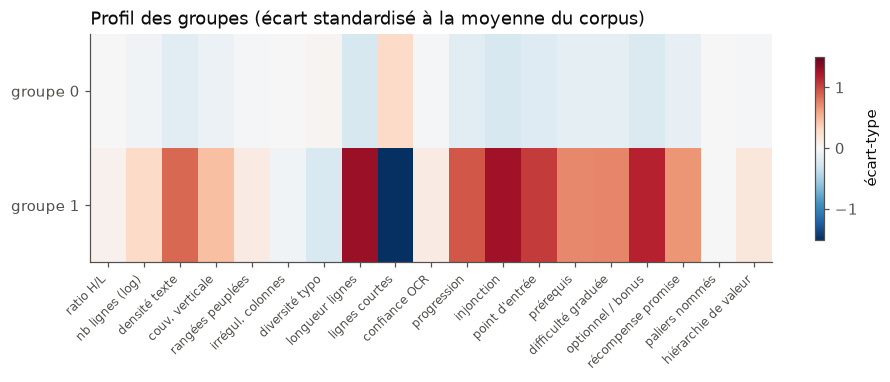

In [7]:
# Profil de chaque groupe : moyenne standardisée de chaque variable.
prof = pd.DataFrame(X, columns=VARS).groupby(traits["cluster"]).mean()
NOMS_V = {"ratio_hauteur_largeur": "ratio H/L", "nb_lignes": "nb lignes (log)",
          "densite_texte": "densité texte", "couverture_verticale": "couv. verticale",
          "part_bandes_peuplees": "rangées peuplées", "regularite_colonnes": "irrégul. colonnes",
          "cv_hauteurs_lignes": "diversité typo", "longueur_moyenne_ligne": "longueur lignes",
          "part_lignes_courtes": "lignes courtes", "confiance_mediane": "confiance OCR"}
etiq = [NOMS_V[v] if v in NOMS_V else NOMS[v].split(" (")[0] for v in VARS]

fig, ax = plt.subplots(figsize=(10, 0.55 * len(prof) + 1.6))
lim = np.abs(prof.values).max()
im = ax.imshow(prof.values, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(VARS)), etiq, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(prof)), [f"groupe {i}" for i in prof.index])
ax.grid(visible=False)
ax.set_title("Profil des groupes (écart standardisé à la moyenne du corpus)", loc="left")
fig.colorbar(im, ax=ax, shrink=0.8, label="écart-type")
figure("fig06_clusters_profils.png", fig)

**Lecture.** Rouge : la variable est au-dessus de la moyenne du corpus dans ce
groupe ; bleu : en dessous (échelle diverging à point médian neutre). Ce profil
donne à chaque groupe sa description opérationnelle — c'est lui qui permet de
*nommer* les types dans le papier (par exemple « catalogues denses muets »,
« guides bavards injonctifs ») plutôt que de les laisser à l'état de numéros.

## 4. Le réseau des auteurs

Deux auteurs sont liés lorsqu'ils figurent sur un même chart. Le réseau est
construit sur le **noyau** (auteurs présents dans au moins 5 charts) à partir de
la table nettoyée `auteurs.csv`. Les « auteurs-passerelles » sont mesurés par la
**centralité d'intermédiarité** : un auteur est passerelle s'il se trouve sur
les chemins courts entre régions du réseau — concrètement, s'il fait le pont
entre des mondes de lecture qui, sans lui, ne se citeraient pas ensemble.

noyau : 124 auteurs, 4312 liens, densité 56.5%


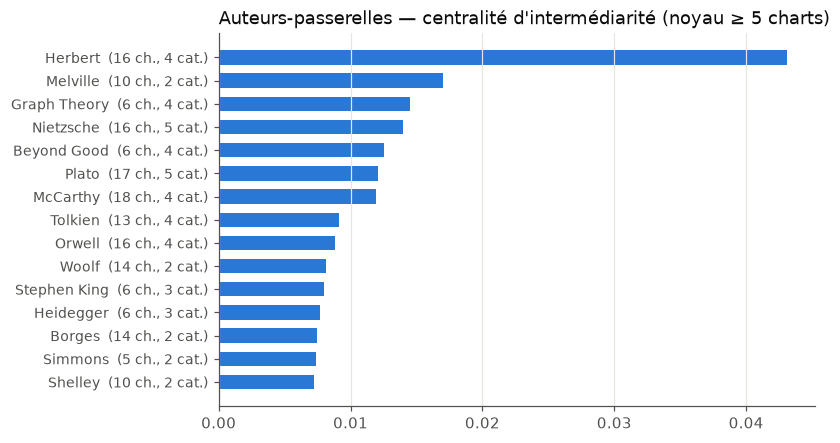

In [8]:
import itertools, networkx as nx

par_chart = auteurs.groupby("fichier")["auteur"].agg(set)
n_charts_de = auteurs.groupby("auteur")["fichier"].nunique()
noyau = set(n_charts_de[n_charts_de >= 5].index)

G = nx.Graph()
for ens in par_chart:
    for a, b in itertools.combinations(sorted(ens & noyau), 2):
        G.add_edge(a, b, weight=G.get_edge_data(a, b, {"weight": 0})["weight"] + 1)
print(f"noyau : {G.number_of_nodes()} auteurs, {G.number_of_edges()} liens, "
      f"densité {nx.density(G):.1%}")

btw = pd.Series(nx.betweenness_centrality(G, weight=None, seed=42)).sort_values()
cats_de = auteurs.groupby("auteur")["categorie"].nunique()
top = btw.tail(15)

fig, ax = plt.subplots(figsize=(7, 4.4))
y = np.arange(len(top))
ax.barh(y, top.values, height=0.62, color=BLEU)
ax.set_yticks(y, [f"{a}  ({n_charts_de[a]} ch., {cats_de[a]} cat.)" for a in top.index],
              fontsize=9)
ax.grid(axis="y", visible=False)
ax.set_title("Auteurs-passerelles — centralité d'intermédiarité (noyau ≥ 5 charts)",
             loc="left")
figure("fig07_passerelles.png", fig)

**Lecture.** L'intermédiarité ne récompense pas la simple popularité : un auteur
peut être très cité mais enfermé dans une région du réseau. Ceux qui dominent ce
classement sont les *ponts* entre mondes — typiquement les auteurs qui
appartiennent à la fois au canon littéraire général et à un corpus spécialisé
(philosophie, SF, religion). Entre parenthèses : le nombre de charts et de
catégories thématiques où chacun apparaît, qui permet de vérifier que la
centralité ne se réduit à aucun des deux.

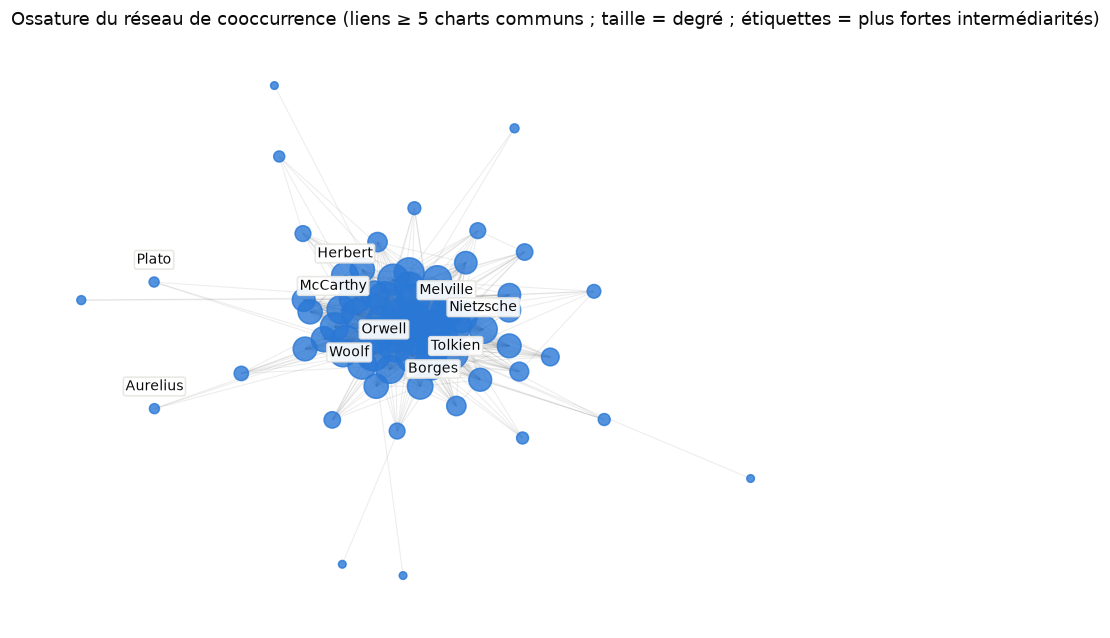

réseau affiché : 72 auteurs, 1082 liens (seuil 5)


In [9]:
# Carte du réseau. Seuil de 5 charts communs : en deçà, la densité du
# noyau (56 %) produit une boule illisible — le seuil ne garde que
# l'ossature, et la légende le déclare.
H = nx.Graph((u, v, d) for u, v, d in G.edges(data=True) if d["weight"] >= 5)
H.remove_nodes_from(list(nx.isolates(H)))
pos = nx.spring_layout(H, seed=42, k=0.9 / np.sqrt(H.number_of_nodes()) * 4)
deg = dict(H.degree)

fig, ax = plt.subplots(figsize=(9.5, 7))
nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.10, width=0.7, edge_color=ENCRE2)
nx.draw_networkx_nodes(H, pos, ax=ax, node_color=BLEU, alpha=0.8,
                       node_size=[16 + 9 * deg[n] for n in H])
# Étiquettes : plus fortes intermédiarités, avec évitement de collisions —
# une étiquette qui tomberait sur une autre est décalée, ou abandonnée.
DECALAGES = [(0, 12), (0, -16), (34, 6), (-34, 6), (30, -14), (-30, -14)]
posees = []
for a in [x for x in btw.index[::-1] if x in pos][:12]:
    x0, y0 = pos[a]
    for dx, dy in DECALAGES:
        xe, ye = x0 + dx / 300, y0 + dy / 300   # repère données approx.
        if all(abs(xe - xp) > 0.16 or abs(ye - yp) > 0.055 for xp, yp in posees):
            ax.annotate(a, pos[a], textcoords="offset points", xytext=(dx, dy),
                        fontsize=9, ha="center", color=ENCRE,
                        bbox=dict(boxstyle="round,pad=0.16", fc="white",
                                  ec=GRILLE, alpha=0.92))
            posees.append((xe, ye))
            break
ax.set_axis_off()
ax.set_title("Ossature du réseau de cooccurrence (liens ≥ 5 charts communs ; "
             "taille = degré ; étiquettes = plus fortes intermédiarités)", loc="left")
figure("fig08_reseau.png", fig)
print(f"réseau affiché : {H.number_of_nodes()} auteurs, {H.number_of_edges()} liens (seuil 5)")

**Lecture.** La masse centrale unique — plutôt que des îlots séparés — est
elle-même un résultat : le canon de /lit/ fonctionne comme un **bloc solidaire**
où citer un auteur entraîne les autres, et non comme une fédération de canons
spécialisés. Les auteurs étiquetés, aux plus fortes intermédiarités, occupent la
lisière entre ce bloc central et les corpus spécialisés qui s'y accrochent.

## 5. Les charts les plus « repostés » — ce que les données permettent

**Mise au point nécessaire.** Le corpus provient du wiki de /lit/, pas d'une
collecte de fils : il ne contient **aucun décompte de reposts**. Mesurer la
recirculation réelle exigerait la phase de collecte d'archives (le scraper
existe, `01_collect.py`, mais l'archive historique de /lit/ n'expose pas d'API).
À défaut, deux approximations honnêtes : les **doublons stricts** (même fichier
classé deux fois dans le wiki) et les **familles de contenu** — charts dont les
ensembles d'auteurs se recouvrent fortement, signature des rééditions et
variantes annuelles qui sont, de fait, la trace d'une recirculation.

--- paires de charts au contenu le plus proche (Jaccard des auteurs) ---
  1.00   07_.sci. cs.jpeg                         ~ 23_Computers.jpeg
  1.00   31_Doomer.jpeg                           ~ 47_Doomer.jpeg
  0.71   06_Romans 1.jpeg                         ~ 07_Romans 2.jpeg
  0.59   01_2014–2020.jpeg                        ~ 04_2016.jpeg
  0.50   01_2014.jpeg                             ~ 01_2014–2020.jpeg
  0.49   01_2014–2020.jpeg                        ~ 06_2018.jpeg
  0.48   04_2016.jpeg                             ~ 06_2018.jpeg
  0.43   01_2014.jpeg                             ~ 04_2016.jpeg
  0.42   01_2014–2020.jpeg                        ~ 05_2017.jpeg
  0.41   01_2014.jpeg                             ~ 03_2015 Authors.jpeg


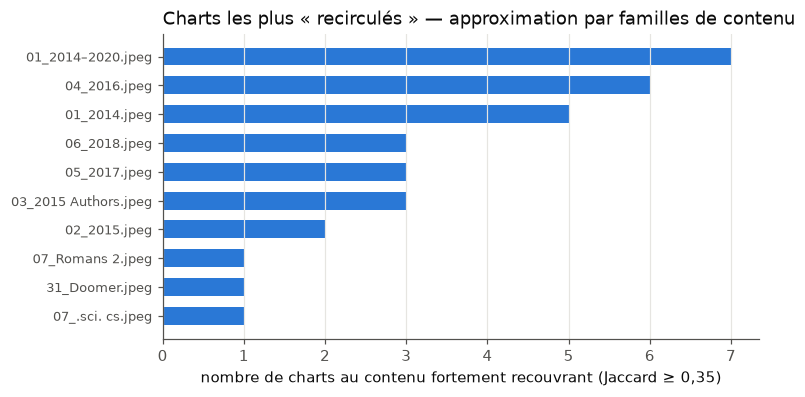

In [10]:
# Recouvrement des ensembles d'auteurs entre charts (Jaccard).
ens = {f: s for f, s in par_chart.items() if len(s) >= 5}
paires = []
for (f1, s1), (f2, s2) in itertools.combinations(ens.items(), 2):
    j = len(s1 & s2) / len(s1 | s2)
    if j >= 0.2:
        paires.append((f1, f2, j))
paires.sort(key=lambda t: -t[2])

print("--- paires de charts au contenu le plus proche (Jaccard des auteurs) ---")
for f1, f2, j in paires[:10]:
    print(f"  {j:.2f}   {f1[:38]:<40} ~ {f2[:38]}")

variantes = pd.Series(0, index=list(ens))
for f1, f2, j in paires:
    if j >= 0.35:
        variantes[f1] += 1; variantes[f2] += 1
top_var = variantes.sort_values().tail(10)

fig, ax = plt.subplots(figsize=(7, 3.6))
y = np.arange(len(top_var))
ax.barh(y, top_var.values, height=0.62, color=BLEU)
ax.set_yticks(y, [f[:44] for f in top_var.index], fontsize=8.5)
ax.grid(axis="y", visible=False)
ax.set_xlabel("nombre de charts au contenu fortement recouvrant (Jaccard ≥ 0,35)")
ax.set_title("Charts les plus « recirculés » — approximation par familles de contenu",
             loc="left")
figure("fig09_familles.png", fig)

**Lecture.** Les familles les plus denses sont les palmarès annuels
(« Top 100 » 2014-2022) : le même dispositif réédité année après année, dont
chaque édition partage l'essentiel de ses auteurs avec les précédentes. C'est la
recirculation *par le contenu* : à défaut de compter les reposts d'images, on
observe que la communauté reposte des **listes** — le chart change d'habillage,
le canon reste. Cette mesure sous-estime les charts à couvertures sans légendes
(auteurs non identifiables par OCR) ; elle est donc un plancher, pas un
classement exhaustif.

## 6. Synthèse pour le papier

| Résultat | Mesure | Source |
|---|---|---|
| Les charts sont d'abord des catalogues | 75 % de grilles/collages ; 20 % de formes prescriptives ; 13 % avec flèches | fig. 1 |
| La gamification est discursive avant d'être visuelle | progression 26 %, injonction 24 % ; paliers nommés 4 %, God-Tier 2 % | fig. 2 |
| Le travail prescriptif est distribué forme/langage | listes : 73 % d'injonctions, score 8,3 ; grilles : score médian 0 | fig. 3 |
| Typologie émergente et sa position | k et ARI imprimés sous la fig. 4 | fig. 4-6 |
| Le canon est un bloc solidaire | densité du noyau imprimée en §4 ; masse centrale unique | fig. 7-8 |
| La recirculation passe par les listes | familles « Top 100 » annuelles au premier rang | fig. 9 |

**Limites à déclarer.** (1) Le codage des formes provient d'un modèle
vision-langage distant — validation externe, non locale (voir `CLAUDE.md`) ; le
modèle local n'atteint pas la fiabilité sur cette variable (α = 0,078) mais
détecte les flèches à α = 0,842. (2) Seules 24 % des mentions d'œuvres portent
un auteur identifiable — les charts à couvertures muettes sont sous-représentés
dans le réseau. (3) Aucune donnée de repost réel : la §5 mesure une
recirculation de contenu, pas d'images. (4) Les marqueurs lexicaux dépendent du
volume de texte du chart ; les scores bruts ne doivent être comparés qu'entre
formes comparables.